# Análise Exploratória de Dados — Olist E-commerce

Este notebook complementa as análises realizadas em Oracle SQL, com foco em:

- distribuição do valor dos pedidos;
- identificação de valores extremos;
- tempo de entrega;
- análise de atrasos;
- relação entre atraso e avaliação;
- comportamento de clientes recorrentes.

O objetivo é explorar os dados visualmente e validar alguns dos principais achados obtidos na etapa SQL.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Carregamento dos dados

Foram utilizados os arquivos brutos da Olist e o arquivo de avaliações tratado anteriormente no processo de preparação dos dados.

In [30]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

products = pd.read_csv("../data/raw/olist_products_dataset.csv")

reviews = pd.read_csv(
    "../data/processed/olist_order_reviews_clean.csv"
)

## 2. Preparação dos dados

As colunas de data foram convertidas para o tipo `datetime` para permitir cálculos de prazo de entrega e atraso.

In [31]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

## 3. Construção da base analítica

A tabela de itens possui granularidade por item do pedido. Para evitar duplicidade de valores, os itens foram agregados por `order_id` antes da união com a tabela de pedidos.

In [32]:
order_sales = (
    items.groupby("order_id", as_index=False)
    .agg(
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

In [33]:
order_sales["total_order_value"] = (
    order_sales["product_value"]
    + order_sales["freight_value"]
)

In [34]:
orders_analytics = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_sales, on="order_id", how="left")
)

In [35]:
delivered = orders_analytics[
    orders_analytics["order_status"] == "delivered"
].copy()

In [36]:
delivered.shape[0]

96478

## 4. Distribuição do valor dos pedidos

Nesta etapa foi analisada a distribuição do valor total dos pedidos entregues, considerando valor dos produtos e frete.

In [37]:
delivered["total_order_value"].describe()

count   96,478.00
mean       159.83
std        218.79
min          9.59
25%         61.85
50%        105.28
75%        176.26
max     13,664.08
Name: total_order_value, dtype: float64

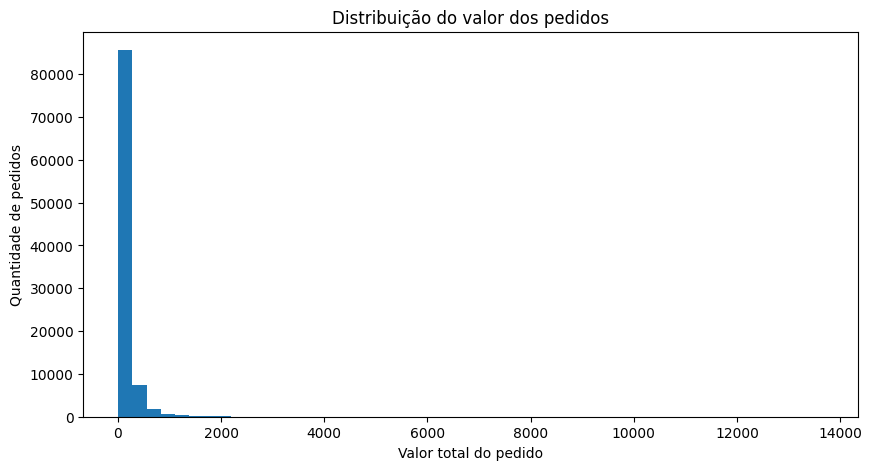

In [38]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivered["total_order_value"],
    bins=50
)

plt.title("Distribuição do valor dos pedidos")
plt.xlabel("Valor total do pedido")
plt.ylabel("Quantidade de pedidos")

plt.show()

In [39]:
delivered.nlargest(
    10,
    "total_order_value"
)[
    [
        "order_id",
        "total_order_value"
    ]
]

,order_id,total_order_value
13390,03caa2c082116e1d31e67e9ae3700499,"13,664.08"
66599,736e1922ae60d0d6a89247b851902527,"7,274.88"
22171,0812eb902a67711a1cb742b3cdaa65ae,"6,929.31"
28326,fefacc66af859508bf1a7934eab1e97f,"6,922.21"
3508,f5136e38d1a14a4dbd87dff67da82701,"6,726.66"
32322,2cc9089445046817a7539d90805e6e5a,"6,081.54"
53352,a96610ab360d42a2e5335a3998b4718a,"4,950.34"
40327,199af31afc78c699f0dbf71fb178d4d4,"4,764.34"
40342,8dbc85d1447242f3b127dda390d56e19,"4,681.78"
11688,426a9742b533fc6fed17d1fd6d143d7e,"4,513.32"


## 5. Tempo de entrega

O tempo de entrega foi calculado pela diferença entre a data de compra e a data efetiva de entrega ao cliente.

In [40]:
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.days

In [41]:
delivered["delivery_days"].describe()

count   96,470.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_days, dtype: float64

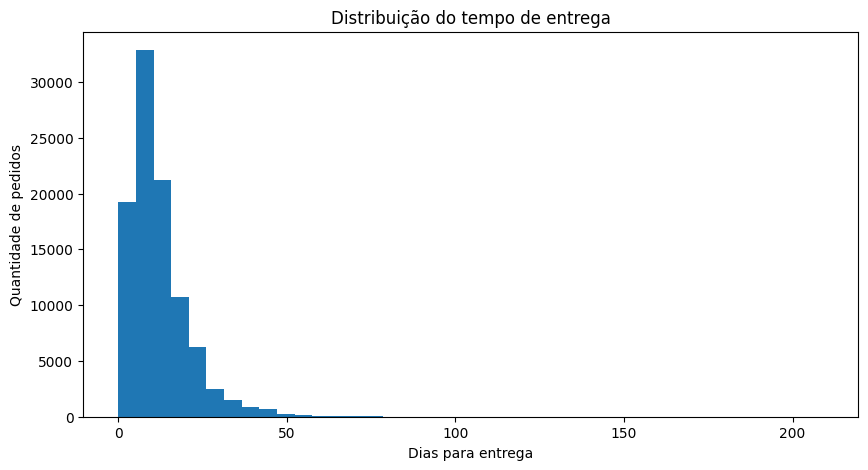

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivered["delivery_days"].dropna(),
    bins=40
)

plt.title("Distribuição do tempo de entrega")
plt.xlabel("Dias para entrega")
plt.ylabel("Quantidade de pedidos")

plt.show()

## 6. Pedidos no prazo x atrasados

Foi calculada a diferença entre a data real de entrega e a data estimada informada ao cliente.

In [43]:
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_estimated_delivery_date"]
).dt.days

In [44]:
delivered["delivery_status"] = delivered["delay_days"].apply(
    lambda x: "Atrasado" if x > 0 else "No prazo"
)

In [45]:
delivered[
    "delivery_status"
].value_counts(normalize=True) * 100

delivery_status
No prazo   93.23
Atrasado    6.77
Name: proportion, dtype: float64

## 7. Relação entre atraso e avaliação

As avaliações foram associadas aos pedidos para verificar se o desempenho logístico apresenta relação com a satisfação dos clientes.

In [46]:
logistics_reviews = delivered.merge(
    reviews[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="inner"
)

In [47]:
logistics_reviews.groupby(
    "delivery_status"
)["review_score"].agg(
    ["count", "mean"]
)

,count,mean
delivery_status,,
Atrasado,6409,2.27
No prazo,89952,4.29


In [48]:
review_by_status = (
    logistics_reviews
    .groupby("delivery_status")["review_score"]
    .mean()
    .reset_index()
)

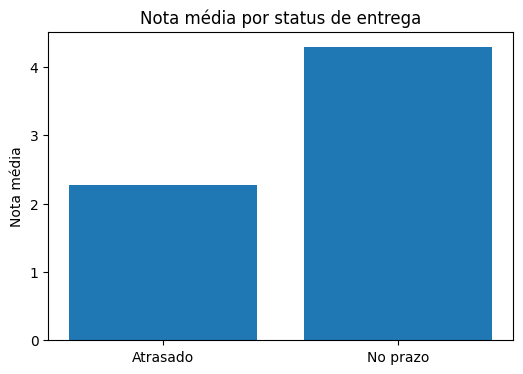

In [49]:
plt.figure(figsize=(6, 4))

plt.bar(
    review_by_status["delivery_status"],
    review_by_status["review_score"]
)

plt.title("Nota média por status de entrega")
plt.ylabel("Nota média")

plt.show()

## 8. Impacto da quantidade de dias de atraso

Para aprofundar a análise, os pedidos foram agrupados em faixas de atraso.

In [50]:
def classify_delay(days):
    if days <= 0:
        return "No prazo"
    elif days <= 3:
        return "1 a 3 dias"
    elif days <= 7:
        return "4 a 7 dias"
    elif days <= 14:
        return "8 a 14 dias"
    elif days <= 30:
        return "15 a 30 dias"
    else:
        return "Mais de 30 dias"

In [51]:
logistics_reviews["delay_range"] = (
    logistics_reviews["delay_days"]
    .apply(classify_delay)
)

In [52]:
delay_review = (
    logistics_reviews
    .groupby("delay_range")
    .agg(
        pedidos=("order_id", "count"),
        nota_media=("review_score", "mean")
    )
    .reset_index()
)

In [53]:
delay_order = [
    "No prazo",
    "1 a 3 dias",
    "4 a 7 dias",
    "8 a 14 dias",
    "15 a 30 dias",
    "Mais de 30 dias"
]

In [54]:
delay_review["delay_range"] = pd.Categorical(
    delay_review["delay_range"],
    categories=delay_order,
    ordered=True
)

delay_review = delay_review.sort_values(
    "delay_range"
)

delay_review

,delay_range,pedidos,nota_media
5,No prazo,89944,4.29
0,1 a 3 dias,1856,3.29
2,4 a 7 dias,1756,2.10
3,8 a 14 dias,1452,1.68
1,15 a 30 dias,1014,1.62
4,Mais de 30 dias,339,2.11


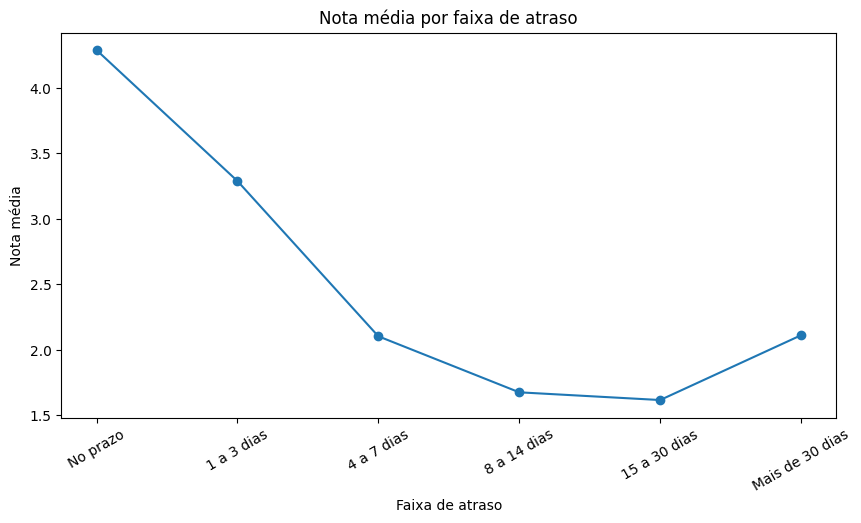

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    delay_review["delay_range"],
    delay_review["nota_media"],
    marker="o"
)

plt.title(
    "Nota média por faixa de atraso"
)

plt.xlabel(
    "Faixa de atraso"
)

plt.ylabel(
    "Nota média"
)

plt.xticks(
    rotation=30
)

plt.show()

## 9. Clientes de compra única x recorrentes

Foi analisado o comportamento dos clientes considerando frequência de compra e valor total gerado.

In [56]:
customer_orders = (
    delivered
    .groupby("customer_unique_id")
    .agg(
        frequency=("order_id", "nunique"),
        monetary=("total_order_value", "sum")
    )
    .reset_index()
)

In [57]:
customer_orders["customer_type"] = (
    customer_orders["frequency"]
    .apply(
        lambda x:
        "Recorrente"
        if x >= 2
        else "Compra única"
    )
)

In [58]:
customer_summary = (
    customer_orders
    .groupby("customer_type")
    .agg(
        clientes=("customer_unique_id", "count"),
        valor_medio=("monetary", "mean"),
        valor_total=("monetary", "sum")
    )
)

customer_summary

,clientes,valor_medio,valor_total
customer_type,,,
Compra única,90557,160.73,"14,555,586.29"
Recorrente,2801,308.53,"864,187.46"


In [59]:
customer_summary_plot = (
    customer_summary
    .reset_index()
)

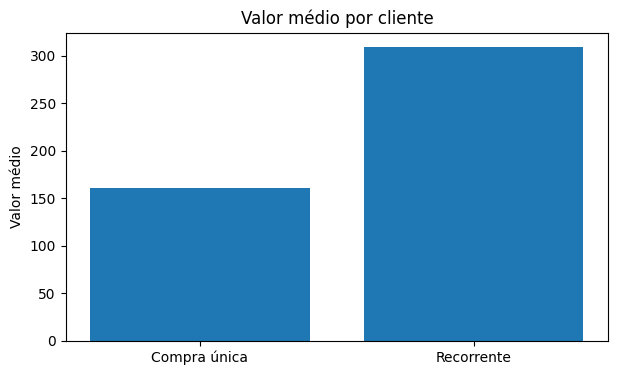

In [60]:
plt.figure(figsize=(7, 4))

plt.bar(
    customer_summary_plot["customer_type"],
    customer_summary_plot["valor_medio"]
)

plt.title(
    "Valor médio por cliente"
)

plt.ylabel(
    "Valor médio"
)

plt.show()

## 10. Principais achados da análise exploratória

A distribuição do valor dos pedidos apresenta forte assimetria positiva. O valor médio dos pedidos é de **R$ 159,83**, enquanto a mediana é de **R$ 105,28**, indicando que uma parcela menor de pedidos de alto valor eleva significativamente a média. O maior pedido observado atingiu **R$ 13.664,08**.

O tempo médio de entrega foi de **12,09 dias**, com mediana de **10 dias**. Também foram identificados casos extremos de entrega, chegando a **209 dias** entre a compra e a entrega ao cliente.

Entre os pedidos entregues com informações suficientes para o cálculo do prazo, **93,23% foram entregues no prazo** e **6,77% apresentaram atraso**.

Apesar de representar uma parcela relativamente pequena das entregas, o atraso está fortemente associado a avaliações piores. Pedidos entregues no prazo apresentaram avaliação média próxima de **4,29**, enquanto atrasos entre **1 e 3 dias** reduziram essa média para aproximadamente **3,29**.

O efeito se intensifica conforme o atraso aumenta. Pedidos com atraso entre **4 e 7 dias** apresentaram avaliação média próxima de **2,10**, enquanto atrasos entre **15 e 30 dias** chegaram a uma avaliação média de aproximadamente **1,62**.

Também foi observada diferença relevante entre clientes de compra única e clientes recorrentes. Embora clientes recorrentes representem uma parcela pequena da base, o valor médio gerado por cliente recorrente é consideravelmente superior ao dos clientes que realizaram apenas uma compra.

Os resultados reforçam dois pontos principais para o negócio: a importância da **retenção de clientes** e o impacto do **desempenho logístico na experiência do consumidor**.